<a href="https://colab.research.google.com/github/aswinclimber/Dog_bread_classification_using_CNN/blob/main/dog_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip "/content/drive/MyDrive/Dog vision/dog-breed-identification.zip" -d "/content/drive/MyDrive/Dog vision/"

Archive:  /content/drive/MyDrive/Dog vision/dog-breed-identification.zip
replace /content/drive/MyDrive/Dog vision/labels.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

### Get our Workspace ready

In [44]:
# importing tensorflow to collab
import tensorflow as tf
print('tf version',tf.__version__)

tf version 2.19.0


In [45]:
import tensorflow_hub as hub

In [ ]:
print(f"hub version {hub.__version__}")

In [ ]:
# Check for GPU
print("GPU", "available (yes!!!!)" if tf.config.list_physical_devices("GPU") else "Not available :(")

# Getting our data ready(turning into tenses) turning our images into tenses(numerical representation)

In [ ]:
import pandas as pd
labels_csv = pd.read_csv('/content/drive/MyDrive/Dog vision/labels.csv')

In [ ]:
labels_csv.head()

In [ ]:
labels_csv.describe()

In [ ]:
# How many images are there for each breed
labels_csv['breed'].value_counts().plot.bar(figsize = (25,15))

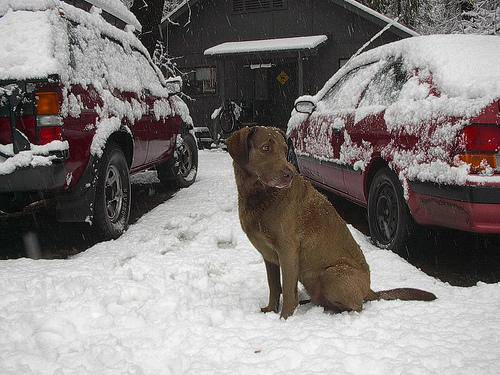

In [10]:
# lets view the image
from IPython.display import Image
Image('/content/drive/MyDrive/Dog vision/train/fff43b07992508bc822f33d8ffd902ae.jpg')

In [11]:
filenames = ['/content/drive/MyDrive/Dog vision/train/'+fname+'.jpg'for fname in labels_csv['id']]
filenames[:10]

['/content/drive/MyDrive/Dog vision/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/content/drive/MyDrive/Dog vision/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/content/drive/MyDrive/Dog vision/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/content/drive/MyDrive/Dog vision/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/content/drive/MyDrive/Dog vision/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 '/content/drive/MyDrive/Dog vision/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 '/content/drive/MyDrive/Dog vision/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 '/content/drive/MyDrive/Dog vision/train/002a283a315af96eaea0e28e7163b21b.jpg',
 '/content/drive/MyDrive/Dog vision/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 '/content/drive/MyDrive/Dog vision/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [12]:
# check wheather number of file names equal to number of actual images files
import os
if len(os.listdir('/content/drive/MyDrive/Dog vision/train/')) == len(filenames):
  print('Filenames match the actual amount of files!!!. proceed.')
else:
  print('filenames do no match the actual amount of files. Check the target directory.')

Filenames match the actual amount of files!!!. proceed.


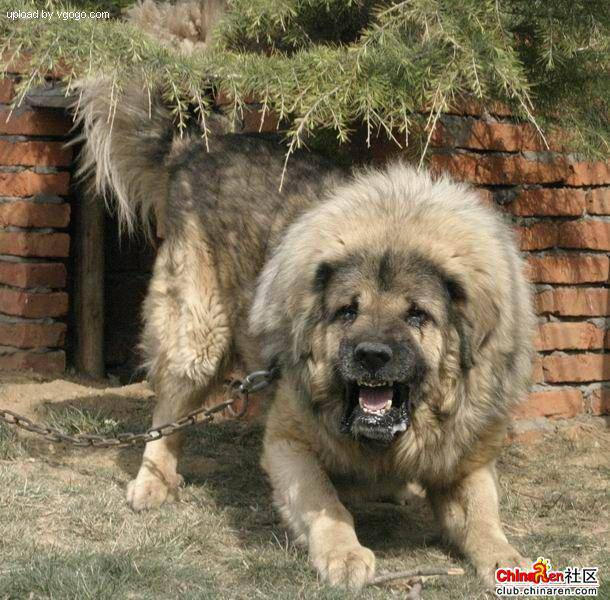

In [13]:
Image(filenames[9000])

In [14]:
labels_csv.iloc[9000]

,9000
id,e20e32bf114141e20a1af854ca4d0ecc
breed,tibetan_mastiff


In [15]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [16]:
import numpy as np
labels = labels_csv['breed'] # or to_numpy
labels = np.array(labels)
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [17]:
len(labels)

10222

In [18]:
# check if number of labels == number of filenames
if len(labels) == len(filenames):
  print('filenames matches the actual amount of labels')
else:
  print('not matched. check data directory')

filenames matches the actual amount of labels


In [19]:
unique_breeds = np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [20]:
# turn a single label into array of booleans
print(labels[0])
labels[0] == unique_breeds

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [21]:
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [22]:
len(boolean_labels)

10222

In [23]:
# turning boolean array's into integers
print(labels[0]) # original label
print(np.where(unique_breeds == labels[0])) # index where label occurs
print(boolean_labels[0].argmax())

boston_bull
(array([19]),)
19


In [24]:
print(labels[2])
print(boolean_labels[2].astype(int))

pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


### creating our own validation set
since the dataset from kaggle doesn't come with validation set. We're going to create our own

In [25]:
# set up X , y variables
X = filenames
y = boolean_labels

In [26]:
len(X)

10222

We're going to start off experimenting with ~images and increase as needed. because 10222 will take a long time

In [27]:
# set number of images for experimenting
NUM_IMAGES = 1000 #@param {type:"slider", min:1000, max:10000,step:1000}

In [28]:
#splting training data for validating
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES], y[:NUM_IMAGES], test_size=0.2, random_state=42)
len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)

## Preprocessing Images (Turning images into tenses)

To preprocess our images into Tensors we're going to write a function which does a few things:
1. Take an image filepath as input
2. Use TensorFlow to read the file and save it to a variable, `image`
3. Turn our `image` (jpg) into Tensors
4. Normalise our image (convert color channel values from 0-255 to 0-1)(scaling)
5. Resize the `image` to be a shape of (224,224)
6. Return the modified `image`

Before we do, let's see what importing am image looks like.

In [30]:
# convert image to numpy array
from matplotlib.pyplot import imread
image = imread(filenames[42])

array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]],

       [[ 56, 104,  66],
        [ 58, 106,  68],
        [ 64, 112,  74],
        ...,
        [ 71, 127,  82],
        [ 73, 129,  84],
        [ 74, 130,  85]],

       ...,

       [[  2,  11,  10],
        [  5,  14,  11],
        [  8,  14,  14],
        ...,
        [120, 113,  67],
        [126, 118,  71],
        [122, 114,  67]],

       [[  0,   3,   7],
        [  2,   7,  10],
        [  3,   9,   7],
        ...,
        [105,  98,  54],
        [112, 104,  58],
        [111, 103,  57]],

       [[ 16,  18,  30],
        [ 16,  19,  24],
        [ 15,  20,  14],
        ...,
        [101,  92,  51],
        [ 97,  88,  47],
        [120, 111,  70]]], dtype=uint8)
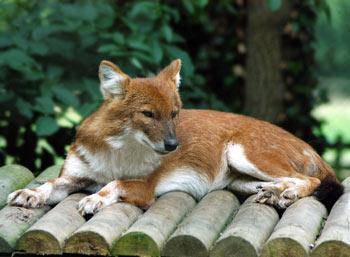

In [31]:
image

In [32]:
image.shape

(257, 350, 3)

In [33]:
image.max(), image.min()

(np.uint8(255), np.uint8(0))

In [34]:
image[:1]

array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]]], dtype=uint8)

In [35]:
# Turn a image into Tensor
tf.constant(image)

<tf.Tensor: shape=(257, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]],

       [[ 56, 104,  66],
        [ 58, 106,  68],
        [ 64, 112,  74],
        ...,
        [ 71, 127,  82],
        [ 73, 129,  84],
        [ 74, 130,  85]],

       ...,

       [[  2,  11,  10],
        [  5,  14,  11],
        [  8,  14,  14],
        ...,
        [120, 113,  67],
        [126, 118,  71],
        [122, 114,  67]],

       [[  0,   3,   7],
        [  2,   7,  10],
        [  3,   9,   7],
        ...,
        [105,  98,  54],
        [112, 104,  58],
        [111, 103,  57]],

       [[ 16,  18,  30],
        [ 16,  19,  24],
        [ 15,  20,  14],
        ...,
        [101,  92,  5

Now we seen how a image looks like when it turns into tensor.Let's make a function to preprocess them.
Take an image filepath as input
Use TensorFlow to read the file and save it to a variable, image
Turn our image (jpg) into Tensors
Resize the image to be a shape of (224,224)
Return the modified image

In [36]:
image_size = 224

In [37]:
def pre_process_image(image_path,IMG_SIZE=image_size):
  """
  Takes an image file path and turns it into a Tensor.
  """
  # read the image file
  image = tf.io.read_file(image_path)
  # turn the jpeg image into tensor
  image = tf.image.decode_jpeg(image,channels=3)
  # convert the color channel values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)
  # Resize our image to (224,224)
  image = tf.image.resize(image, size=[IMG_SIZE,IMG_SIZE])
  return image



## Turning our data into batches

Why turn our data into batches?

Let's say you're trying to process 10,000 + images in one go... they all might nor fit into memory.

So that's why we do about 32 images at a time.

In order to use TensorFlow effectively, we need our data in the form of Tensor tuples which look like this:
`(image, label)`

In [38]:
# create a simple function to return a tuple (image, label)
def get_image_label(image_path,label):
  """
  Takes an image file path name and the assosciated label,
  processs the image and returns a tuple of (image, label)
  """
  image = pre_process_image(image_path)
  return image, label

In [39]:
# Demo of above
(pre_process_image(X[42]),tf.constant(y[42]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117759],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

Now we've got a way to turn our data into tuples of Tensors in the form: `(image, label)`, let's make a function to turn all of our data `(X & y)` into batches!

In [40]:
batch_size = 32

#create a function to turn data into batches
def create_data_batches(X, y=None, batch_size=batch_size, valid_data=False, test_data=False):
  """
  creates batches of data out of image (X) and label (y) pairs.
  Shuffles the data if it's training data but doesn't shuffle if its validation data.
  Also accepts test data as input (no labels).
  """
  # if data is test data, we don't have labels
  if test_data:
    print("Creating test data batches...")
    data = tf.data.Dataset.from_tensor_slices(tf.constant(X)) # only filepaths no labels
    data_batch = data.map(pre_process_image).batch(batch_size)
    return data_batch
  # if data is valid dataset, we don't need to shuffle it
  elif valid_data:
    print("Creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), # file path
                                               tf.constant(y))) # labels
    data_batch = data.map(get_image_label).batch(batch_size)
    return data_batch

  else:
    print("Creating training data batches...")
    # turn filepaths and labels into Tensors
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),
                                               tf.constant(y)))
    # shuffling pathnames and labels before mapping becuase it is more faster way of execution
    data = data.shuffle(buffer_size=len(X))
    # create (image, label) tuples (This also turns the image path into a preprocessed image) and turn the training data into batches
    data_batch = data.map(get_image_label).batch(batch_size)
  return data_batch

In [41]:
# create training and validation data batches
train_data = create_data_batches(X_train, y_train)
valid_data = create_data_batches(X_val, y_val, valid_data=True)

Creating training data batches...
Creating validation data batches...


In [42]:
#check out diff attributes of our data batches
train_data.element_spec, valid_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

## Visualizing data batches
our data is now batches, however , these can be a little hard to undertand/comprehend, let's visualize them

In [49]:
train_images, train_labels = next(train_data.as_numpy_iterator())
train_images, train_labels

(array([[[[1.41028762e-01, 2.69480914e-01, 4.28154588e-01],
          [1.77305475e-01, 2.95073986e-01, 4.42682087e-01],
          [2.11455062e-01, 3.07378113e-01, 4.37338084e-01],
          ...,
          [1.86357096e-01, 3.29138517e-01, 3.74490499e-01],
          [1.72726199e-01, 3.52044553e-01, 4.04536188e-01],
          [8.60665739e-02, 2.77796805e-01, 3.36236358e-01]],
 
         [[1.98246032e-01, 3.13931227e-01, 4.55000460e-01],
          [1.60616919e-01, 2.62168497e-01, 3.91211510e-01],
          [2.02492565e-01, 2.84644186e-01, 3.90561551e-01],
          ...,
          [1.69201046e-01, 3.06054294e-01, 3.50575775e-01],
          [1.31777838e-01, 3.03084373e-01, 3.50483567e-01],
          [1.51509672e-01, 3.41044009e-01, 3.97586316e-01]],
 
         [[1.91959918e-01, 2.88037270e-01, 4.04169977e-01],
          [1.68719381e-01, 2.49382913e-01, 3.49014163e-01],
          [4.34082925e-01, 4.89591002e-01, 5.50094128e-01],
          ...,
          [3.52190733e-01, 4.81691062e-01, 5.1672

In [50]:
len(train_images),len(train_labels)

(32, 32)

In [43]:
import matplotlib.pyplot as plt
# create a function for viewing images in data batch
def show_25_images(images, labels):
  """
  Displays a plot of 25 images and their labels from a data batch
  """
  #set the figure
  plt.figure(figsize=(10,10))
  # loop through 25 (for displaying 25 images)
  for i in range(25):
    # create Sub plots (5 rows, 5 columns)
    ax = plt.subplot(5,5,i+1)
    # display the image
    plt.imshow(images[i])
    # Add the image label as the title
    plt.title(unique_breeds[labels[i].argmax()])
    # Turn the grid lines off
    # plt.axis("off")
